In [1]:
import anndata as ad
import scipy.sparse as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [2]:
DATASET = "seaad_paired_sub42"
BASE    = f"../../../data/processed/{DATASET}"

rna      = ad.read_h5ad(f"output/{DATASET}_with_networks_seed42.h5ad")
oob_df = rna.obsm["wScReNI_oob_r2"]


In [3]:
print("Shape:", oob_df.shape)
print("\nPer-gene R$^2$ (averaged across cells):")
print(oob_df.mean(axis=0).describe())

print("\nPer-cell R$^2$ (averaged across genes):")
print(oob_df.mean(axis=1).describe())

print(f"\nNaN genes (zero expression, skipped): {oob_df.isna().sum().sum()} / {oob_df.size}")
print(f"Negative R$^2$ genes: {(oob_df < 0).sum().sum()}")

Shape: (1200, 500)

Per-gene R$^2$ (averaged across cells):
count    498.000000
mean      -0.071154
std        0.028725
min       -0.128583
25%       -0.091854
50%       -0.077694
75%       -0.057477
max        0.036441
dtype: float64

Per-cell R$^2$ (averaged across genes):
count    1200.000000
mean       -0.065008
std         0.032080
min        -0.121909
25%        -0.085372
50%        -0.071175
75%        -0.050546
max         0.291942
dtype: float64

NaN genes (zero expression, skipped): 267970 / 600000
Negative R$^2$ genes: 265479


In [4]:
gene_r2 = oob_df.mean(axis=0)
gene_r2_sorted = gene_r2.sort_values(ascending=False)

print(gene_r2_sorted.head(20))
print(gene_r2_sorted.tail(20))

ERBB4       0.036441
KIAA1217    0.027277
DLC1        0.022931
PARD3       0.022790
ZNF385D     0.015453
KCNIP1      0.008465
MYO16       0.008227
SDK1        0.007824
SGCZ        0.005025
GRIN3A      0.001614
MARCO       0.000348
ONECUT1    -0.001494
PLD5       -0.001669
FGF13      -0.003294
ALK        -0.003835
NXPH1      -0.005744
ADARB2     -0.005892
NKAIN3     -0.006604
GRIK1      -0.008285
SLC1A2     -0.009264
dtype: float64
AC079380.1   -0.109012
RXFP2        -0.109616
AC018742.1   -0.109908
AC096637.1   -0.110009
AC093898.1   -0.110050
AC112770.1   -0.110239
AC069410.1   -0.111141
AC073941.1   -0.111776
LINC01099    -0.112124
LINC01324    -0.114820
AC008568.1   -0.117629
AL445255.1   -0.119408
PENK         -0.119573
AC018680.1   -0.120737
AL390800.1   -0.121405
ADH1B        -0.122367
AL353811.1   -0.127983
CXCL10       -0.128583
IL1B               NaN
AC010086.3         NaN
dtype: float64


C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\1812623413.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


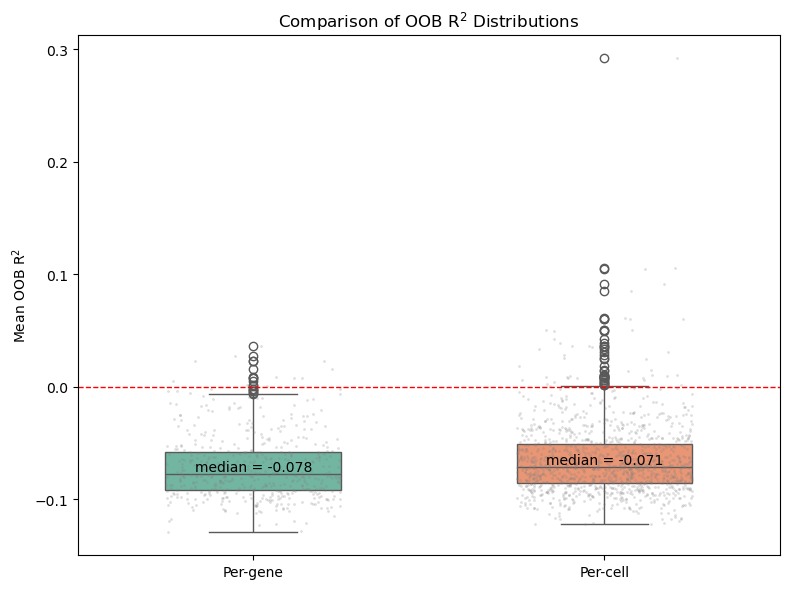

In [5]:
plt.style.use('default')

gene_r2 = oob_df.mean(axis=0)
cell_r2 = oob_df.mean(axis=1)

compare_df = pd.DataFrame({
    "R2": np.concatenate([gene_r2.values, cell_r2.values]),
    "Type": (["Per-gene"] * len(gene_r2)) +
            (["Per-cell"] * len(cell_r2))
})

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=compare_df,
    x="Type",
    y="R2",
    palette="Set2",
    width=0.5,
    ax=ax
)

sns.stripplot(
    data=compare_df,
    x="Type",
    y="R2",
    color="gray",
    alpha=0.25,
    size=2,
    jitter=0.25,
    ax=ax
)

ax.axhline(0, color="red", linestyle="--", linewidth=1)

ax.set_title("Comparison of OOB R$^2$ Distributions")
ax.set_xlabel("")
ax.set_ylabel("Mean OOB R$^2$")

gene_median = gene_r2.median()
cell_median = cell_r2.median()

ax.text(
    0,
    gene_median,
    f"median = {gene_median:.3f}",
    ha="center",
    va="bottom",
    fontsize=10
)

ax.text(
    1,
    cell_median,
    f"median = {cell_median:.3f}",
    ha="center",
    va="bottom",
    fontsize=10
)

plt.tight_layout()
plt.savefig("oob_r2_comparison_boxplot.png", dpi=150)
plt.show()

In [6]:
networks = np.load(f"output/{DATASET}_networks_seed42.npy")

In [7]:
gene_r2 = oob_df.mean(axis=0)
cell_r2 = oob_df.mean(axis=1)

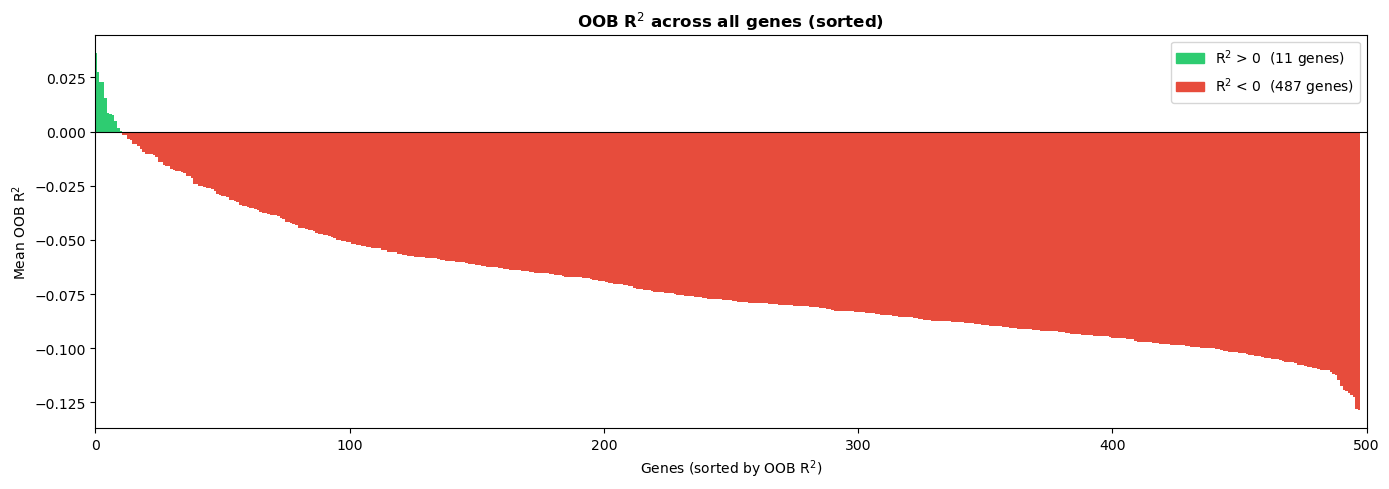

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

gene_r2_sorted = gene_r2.sort_values(ascending=False).reset_index(drop=True)

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in gene_r2_sorted]

ax.bar(range(len(gene_r2_sorted)), gene_r2_sorted.values, color=colors, width=1.0, edgecolor="none")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Genes (sorted by OOB R$^2$)")
ax.set_ylabel("Mean OOB R$^2$")
ax.set_title("OOB R$^2$ across all genes (sorted)", fontweight="bold")
ax.set_xlim(0, len(gene_r2_sorted))


from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2ecc71", label=f"R$^2$ > 0  ({(gene_r2 > 0).sum()} genes)"),
    Patch(color="#e74c3c", label=f"R$^2$ < 0  ({(gene_r2 < 0).sum()} genes)"),
], loc="upper right")

plt.tight_layout()
plt.savefig("oob_r2_all_genes.png", dpi=150, bbox_inches="tight")
plt.show()

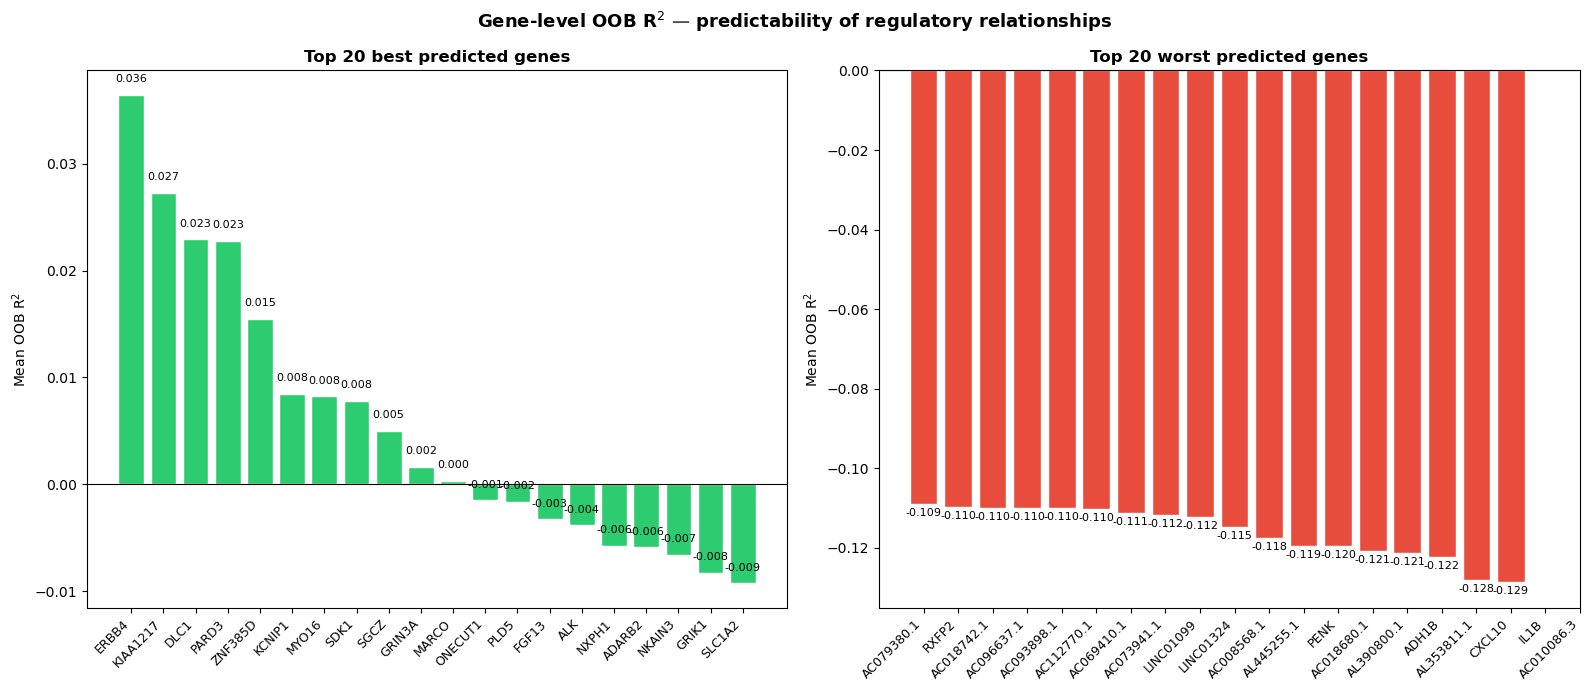

Genes with R$^2$ > 0 : 11 / 500
Genes with R$^2$ < 0 : 487 / 500


In [9]:
top_n = 20
best  = gene_r2.sort_values(ascending=False).head(top_n)
worst = gene_r2.sort_values(ascending=False).tail(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

bars = axes[0].bar(range(len(best)), best.values, color="#2ecc71", edgecolor="white")
axes[0].set_xticks(range(len(best)))
axes[0].set_xticklabels(best.index, fontsize=9, rotation=45, ha="right")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Mean OOB R$^2$")
axes[0].set_title(f"Top {top_n} best predicted genes", fontweight="bold")

for bar, val in zip(bars, best.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.001,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8)

bars = axes[1].bar(range(len(worst)), worst.values, color="#e74c3c", edgecolor="white")
axes[1].set_xticks(range(len(worst)))
axes[1].set_xticklabels(worst.index, fontsize=9, rotation=45, ha="right")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Mean OOB R$^2$")
axes[1].set_title(f"Top {top_n} worst predicted genes", fontweight="bold")

for bar, val in zip(bars, worst.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val - 0.001,
                 f"{val:.3f}", ha="center", va="top", fontsize=8)

fig.suptitle("Gene-level OOB R$^2$ — predictability of regulatory relationships",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("oob_r2_per_gene.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Genes with R$^2$ > 0 : {(gene_r2 > 0).sum()} / {len(gene_r2)}")
print(f"Genes with R$^2$ < 0 : {(gene_r2 < 0).sum()} / {len(gene_r2)}")

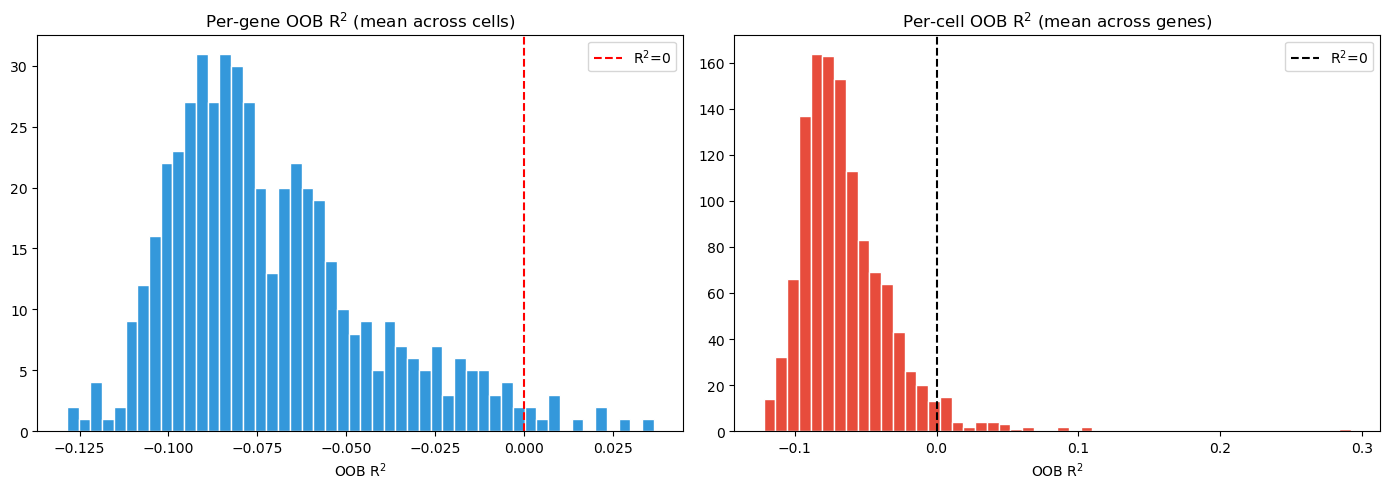

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(gene_r2.dropna(), bins=50, color="#3498db", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", label="R$^2$=0")
axes[0].set_title("Per-gene OOB R$^2$ (mean across cells)")
axes[0].set_xlabel("OOB R$^2$")
axes[0].legend()

axes[1].hist(cell_r2.dropna(), bins=50, color="#e74c3c", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", label="R$^2$=0")
axes[1].set_title("Per-cell OOB R$^2$ (mean across genes)")
axes[1].set_xlabel("OOB R$^2$")
axes[1].legend()

plt.tight_layout()
plt.savefig("oob_r2_distributions.png", dpi=150)
plt.show()

C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\797034373.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = cell_r2_df.groupby("cell_type")["cell_r2"].median().sort_values(ascending=False).index
C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\797034373.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cell_r2_df, x="cell_type", y="cell_r2",


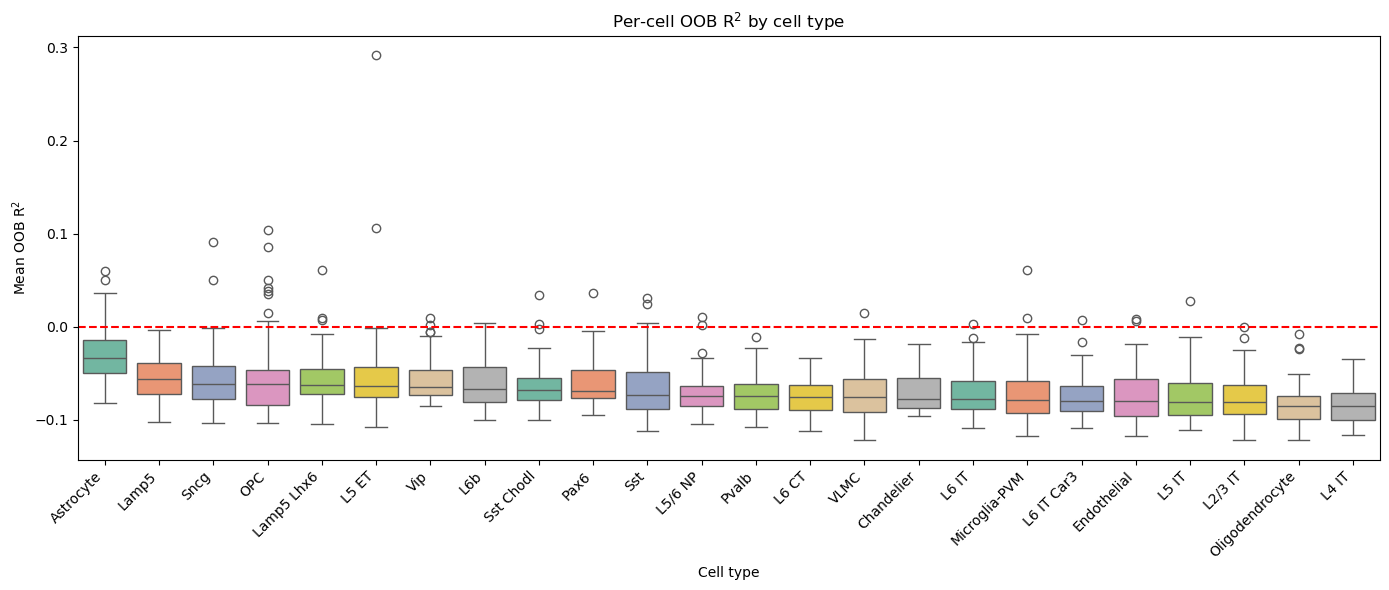

In [11]:
cell_type = rna.obs["cell_type"].copy()
cell_type[cell_type.isin(["nan", "None", "<NA>"])] = np.nan

cell_r2_df = pd.DataFrame({
    "cell_r2":   cell_r2.values,
    "cell_type": cell_type.values,
})

order = cell_r2_df.groupby("cell_type")["cell_r2"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=cell_r2_df, x="cell_type", y="cell_r2",
            order=order, ax=ax, palette="Set2")
ax.axhline(0, color="red", linestyle="--")
ax.set_title("Per-cell OOB R$^2$ by cell type")
ax.set_xlabel("Cell type")
ax.set_ylabel("Mean OOB R$^2$")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("oob_r2_by_celltype.png", dpi=150)
plt.show()

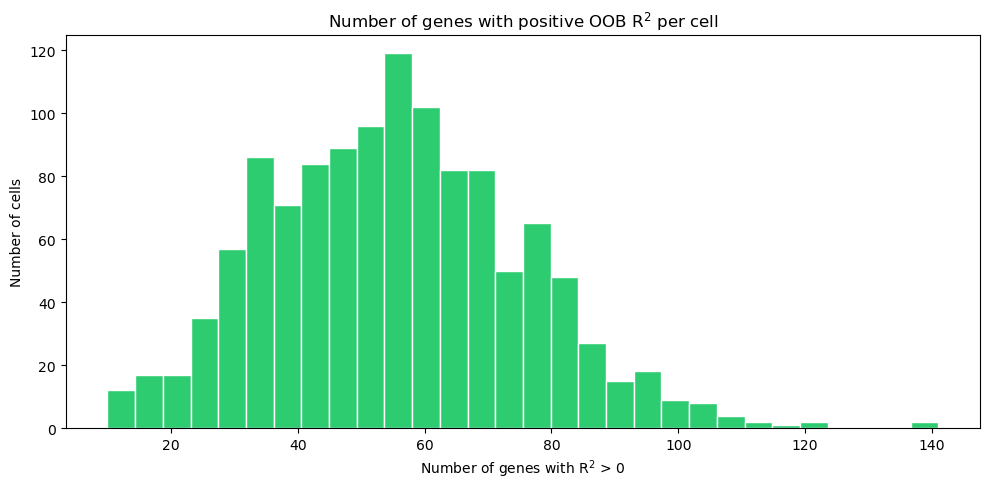

In [12]:
n_positive = (oob_df > 0).sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(n_positive, bins=30, color="#2ecc71", edgecolor="white")
ax.set_title("Number of genes with positive OOB R$^2$ per cell")
ax.set_xlabel("Number of genes with R$^2$ > 0")
ax.set_ylabel("Number of cells")
plt.tight_layout()
plt.savefig("oob_positive_genes_per_cell.png", dpi=150)
plt.show()

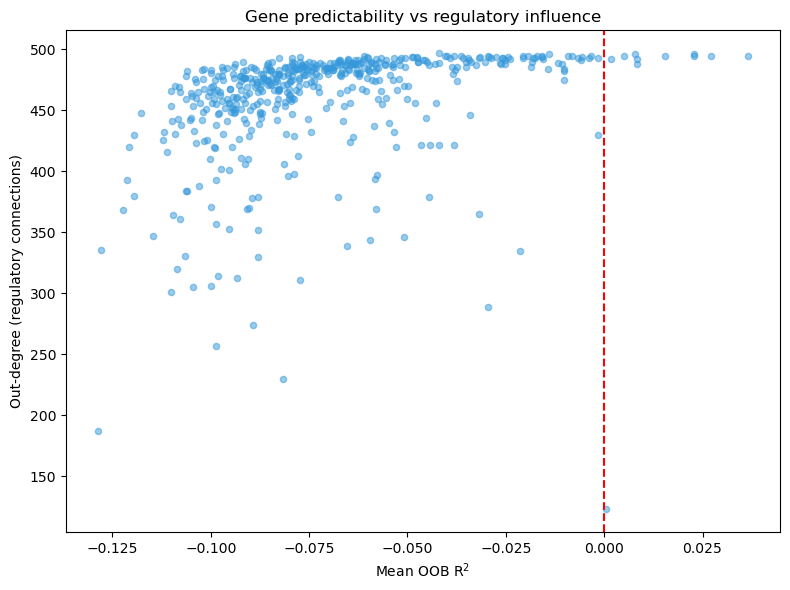

         gene  mean_oob_r2  out_degree
81      ERBB4     0.036441         495
329  KIAA1217     0.027277         495
268      DLC1     0.022931         495
332     PARD3     0.022790         496
87    ZNF385D     0.015453         495
206    KCNIP1     0.008465         492
411     MYO16     0.008227         488
234      SDK1     0.007824         496
270      SGCZ     0.005025         495
317    GRIN3A     0.001614         492


In [13]:
networks   = np.load("output/seaad_paired_sub42_networks.npy")
mean_net   = networks.mean(axis=0)

out_degree = (mean_net > 0).sum(axis=0)

degree_df = pd.DataFrame({
    "gene":       rna.var_names,
    "mean_oob_r2": gene_r2.values,
    "out_degree":  out_degree,
}).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(degree_df["mean_oob_r2"], degree_df["out_degree"],
           alpha=0.5, s=20, color="#3498db")
ax.set_xlabel("Mean OOB R$^2$")
ax.set_ylabel("Out-degree (regulatory connections)")
ax.set_title("Gene predictability vs regulatory influence")
ax.axvline(0, color="red", linestyle="--")
plt.tight_layout()
plt.savefig("oob_vs_outdegree.png", dpi=150)
plt.show()

print(degree_df.sort_values("mean_oob_r2", ascending=False).head(10))

In [14]:
cell_r2 = oob_df.mean(axis=1)

cell_type = rna.obs["cell_type"].copy()
cell_type[cell_type.isin(["nan", "None", "<NA>"])] = np.nan

l5et_mask  = cell_type == "L5 ET"
l5et_r2    = cell_r2[l5et_mask]
l5et_idx   = np.where(l5et_mask)[0]

print(f"L5 ET cells: {l5et_mask.sum()}")
print(l5et_r2.describe())

q_high = l5et_r2.quantile(0.90)
q_low  = l5et_r2.quantile(0.10)

high_mask = l5et_r2 >= q_high
low_mask  = l5et_r2 <= q_low

high_idx = l5et_idx[high_mask.values]
low_idx  = l5et_idx[low_mask.values]

print(f"High accuracy cells (top 10%): {len(high_idx)}, threshold R$^2$={q_high:.4f}")
print(f"Low accuracy cells (bot 10%):  {len(low_idx)}, threshold R$^2$={q_low:.4f}")

L5 ET cells: 50
count    50.000000
mean     -0.049883
std       0.059539
min      -0.107792
25%      -0.075899
50%      -0.063096
75%      -0.043486
max       0.291942
dtype: float64
High accuracy cells (top 10%): 5, threshold R$^2$=-0.0178
Low accuracy cells (bot 10%):  5, threshold R$^2$=-0.0884


In [15]:
print(f"L5 ET cells total: {l5et_mask.sum()}")
print(l5et_r2.sort_values(ascending=False).head(10))
print("...")
print(l5et_r2.sort_values(ascending=True).head(10))

L5 ET cells total: 50
exp_component_name
CCTTAGTGTTGTTGGA-L8XR_210812_01_A12-1124987483    0.291942
GCCCTCATCGGCTAGC-L8XR_210729_01_B09-1122543706    0.105977
AGTAACCTCTTAAGTG-L8XR_210722_01_B08-1122543704   -0.001014
TCGCCCATCGCTTCTA-L8XR_210722_01_B08-1122543704   -0.014027
AGCATTTCATCCTAGA-L8XR_210812_01_A12-1124987483   -0.014617
TTATGCGCAATAATGG-L8XR_210722_01_H07-1122543705   -0.018186
CGTCAATAGGTCTTGG-L8XR_210722_01_B08-1122543704   -0.018199
TATAGCCAGTTCCTCA-L8XR_211007_02_F03-1135448413   -0.024625
TTGCGTCTCTTTAGGA-L8XR_211007_02_C04-1135704089   -0.030308
GTACTTAAGCTGCACA-L8XR_211014_02_D05-1136687625   -0.037993
dtype: float64
...
exp_component_name
CGGTAACGTGCGCATG-L8XR_210805_01_H09-1124629228   -0.107792
GATTCAGGTCCGGTTC-L8XR_210805_01_H09-1124629228   -0.097036
GATTCAATCGTGCCTT-L8XR_210812_01_D11-1124987482   -0.095640
GCTAATATCCTTGAGG-L8XR_210715_01_A12-1121939868   -0.089458
CTGGCTAAGCCGGTAC-L8XR_210805_01_H09-1124629228   -0.088492
CTATTGAAGGGTGAGT-L8XR_210729_01_C09-

High accuracy cells: 1
Low accuracy cells : 1

High R$^2$ values: [0.29194156]
Low R$^2$ values : [-0.10779231]


C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\646903048.py:41: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pval = mannwhitneyu(high_corrs, low_corrs, alternative="greater")
C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\646903048.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([high_corrs, low_corrs], labels=["High accuracy", "Low accuracy"],


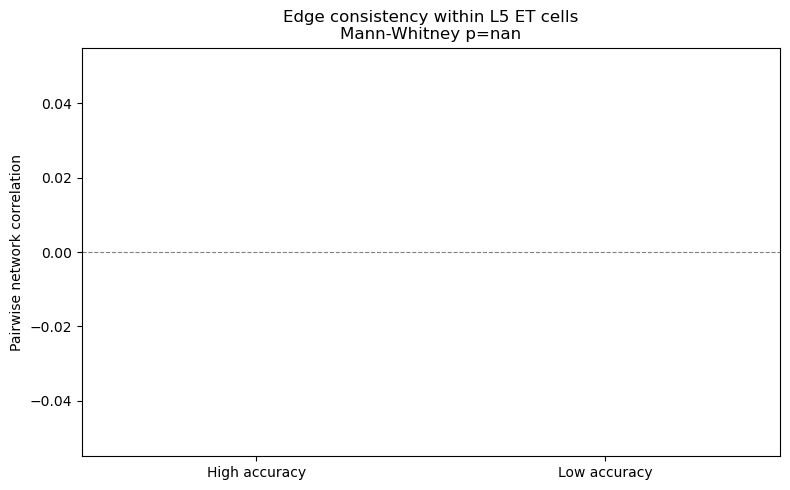

High accuracy mean correlation: nan
Low accuracy mean correlation:  nan


C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\646903048.py:56: RuntimeWarning: Mean of empty slice.
  print(f"High accuracy mean correlation: {high_corrs.mean():.4f}")
D:\Edi\TU Delft\Research Project\bsc-screni\.pixi\envs\default\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\646903048.py:57: RuntimeWarning: Mean of empty slice.
  print(f"Low accuracy mean correlation:  {low_corrs.mean():.4f}")


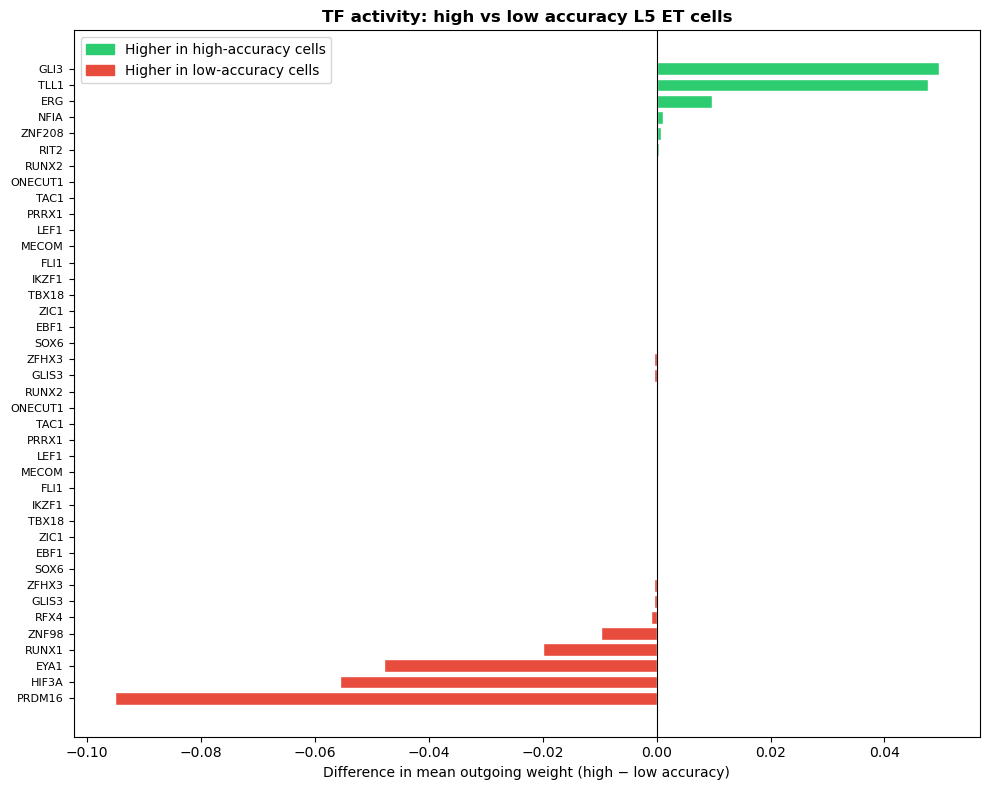


Top TFs more active in HIGH accuracy cells:
         TF  high_activity  low_activity      diff
24     GLI3       0.049550      0.000000  0.049550
13     TLL1       0.047619      0.000000  0.047619
3       ERG       0.059680      0.049912  0.009768
17     NFIA       0.048834      0.047802  0.001032
19   ZNF208       0.048330      0.047619  0.000710
1      RIT2       0.048121      0.047749  0.000372
20    RUNX2       0.047911      0.047754  0.000157
21  ONECUT1       0.047627      0.047622  0.000005
0      TAC1       0.000000      0.000000  0.000000
5     PRRX1       0.000000      0.000000  0.000000

Top TFs more active in LOW accuracy cells:
        TF  high_activity  low_activity      diff
15    EBF1       0.000000      0.000000  0.000000
2     SOX6       0.048142      0.048330 -0.000187
18   ZFHX3       0.047633      0.048038 -0.000405
10   GLIS3       0.047619      0.048086 -0.000467
23    RFX4       0.047619      0.048568 -0.000948
11   ZNF98       0.048449      0.058174 -0.009725


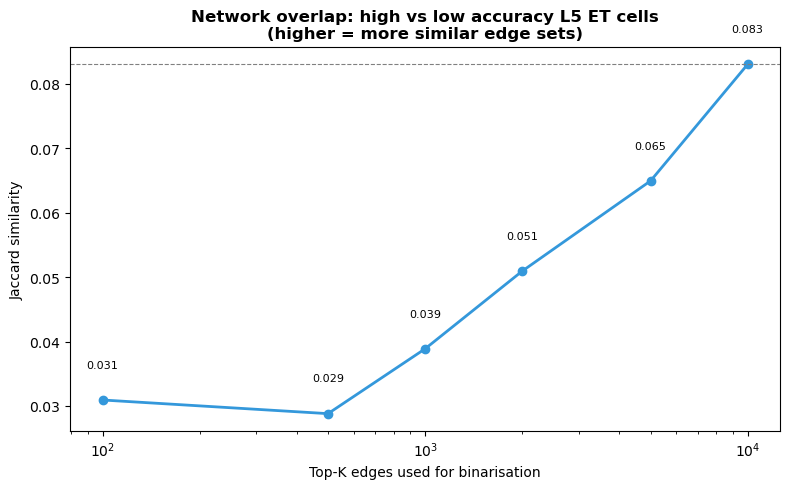

In [16]:
from scipy.stats import mannwhitneyu


networks = np.load(f"output/{DATASET}_networks.npy")
gene_names = rna.var_names.tolist()
gene_to_idx = {g: i for i, g in enumerate(gene_names)}

labels   = pd.read_csv(f"{BASE}_gene_labels.csv")
tf_genes = set(labels[labels["type"] == "TF"]["gene"])
tf_idxs  = [i for i, g in enumerate(gene_names) if g in tf_genes]

l5et_r2_sorted = l5et_r2.sort_values(ascending=False)

high_cells = l5et_r2_sorted.head(1).index
low_cells  = l5et_r2_sorted.tail(1).index

high_idx = np.where(rna.obs_names.isin(high_cells))[0]
low_idx  = np.where(rna.obs_names.isin(low_cells))[0]

high_networks = networks[high_idx]
low_networks  = networks[low_idx]

print(f"High accuracy cells: {len(high_idx)}")
print(f"Low accuracy cells : {len(low_idx)}")
print(f"\nHigh R$^2$ values: {l5et_r2[high_cells].values}")
print(f"Low R$^2$ values : {l5et_r2[low_cells].values}")

def pairwise_correlations(nets):
    n = len(nets)
    flat = nets.reshape(n, -1)
    corrs = []
    for i in range(n):
        for j in range(i+1, n):
            c = np.corrcoef(flat[i], flat[j])[0, 1]
            corrs.append(c)
    return np.array(corrs)

high_corrs = pairwise_correlations(high_networks)
low_corrs  = pairwise_correlations(low_networks)

stat, pval = mannwhitneyu(high_corrs, low_corrs, alternative="greater")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([high_corrs, low_corrs], labels=["High accuracy", "Low accuracy"],
           patch_artist=True,
           boxprops=dict(facecolor="#2ecc71", alpha=0.7),
           medianprops=dict(color="black", linewidth=2))
ax.set_ylabel("Pairwise network correlation")
ax.set_title("Edge consistency within L5 ET cells\n"
             f"Mann-Whitney p={pval:.4f}")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("l5et_edge_consistency.png", dpi=150)
plt.show()

print(f"High accuracy mean correlation: {high_corrs.mean():.4f}")
print(f"Low accuracy mean correlation:  {low_corrs.mean():.4f}")


high_mean_net = high_networks.mean(axis=0)
low_mean_net  = low_networks.mean(axis=0)

tf_activity = []
for tf in tf_genes:
    if tf not in gene_to_idx:
        continue
    idx = gene_to_idx[tf]
    high_out = high_mean_net[:, idx].sum()
    low_out  = low_mean_net[:, idx].sum()
    tf_activity.append({
        "TF":         tf,
        "high_activity": high_out,
        "low_activity":  low_out,
        "diff":          high_out - low_out,
    })

tf_df = pd.DataFrame(tf_activity).sort_values("diff", ascending=False)

top_tf    = tf_df.head(20)
bottom_tf = tf_df.tail(20)
plot_tf   = pd.concat([top_tf, bottom_tf])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in plot_tf["diff"]]
ax.barh(range(len(plot_tf)), plot_tf["diff"].values, color=colors, edgecolor="white")
ax.set_yticks(range(len(plot_tf)))
ax.set_yticklabels(plot_tf["TF"].values, fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Difference in mean outgoing weight (high − low accuracy)")
ax.set_title("TF activity: high vs low accuracy L5 ET cells", fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2ecc71", label="Higher in high-accuracy cells"),
    Patch(color="#e74c3c", label="Higher in low-accuracy cells"),
])
plt.tight_layout()
plt.savefig("l5et_tf_activity.png", dpi=150)
plt.show()

print("\nTop TFs more active in HIGH accuracy cells:")
print(tf_df.head(10)[["TF", "high_activity", "low_activity", "diff"]].to_string())
print("\nTop TFs more active in LOW accuracy cells:")
print(tf_df.tail(10)[["TF", "high_activity", "low_activity", "diff"]].to_string())


def binarise(net, threshold=None, top_k=None):
    if top_k is not None:
        flat = net.flatten()
        threshold = np.sort(flat)[-top_k]
    return (net >= threshold).astype(int)

def jaccard(a, b):
    intersection = (a & b).sum()
    union        = (a | b).sum()
    return intersection / union if union > 0 else 0.0

TOP_K = 1000
high_bin = binarise(high_mean_net, top_k=TOP_K)
low_bin  = binarise(low_mean_net,  top_k=TOP_K)

j_score = jaccard(high_bin, low_bin)
print(f"\nJaccard similarity (top {TOP_K} edges): {j_score:.4f}")

top_ks  = [100, 500, 1000, 2000, 5000, 10000]
jaccards = [jaccard(binarise(high_mean_net, top_k=k),
                    binarise(low_mean_net,  top_k=k)) for k in top_ks]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(top_ks, jaccards, marker="o", color="#3498db", linewidth=2)
ax.set_xlabel("Top-K edges used for binarisation")
ax.set_ylabel("Jaccard similarity")
ax.set_title("Network overlap: high vs low accuracy L5 ET cells\n"
             "(higher = more similar edge sets)", fontweight="bold")
ax.set_xscale("log")
ax.axhline(jaccards[-1], color="grey", linestyle="--", linewidth=0.8)
for k, j in zip(top_ks, jaccards):
    ax.text(k, j + 0.005, f"{j:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("l5et_jaccard.png", dpi=150)
plt.show()

In [17]:
cell_r2 = oob_df.mean(axis=1)
print(cell_r2.describe())
print(f"\nTop 10% threshold : {cell_r2.quantile(0.90):.4f}")
print(f"Bottom 10% threshold: {cell_r2.quantile(0.10):.4f}")
print(f"\nTop 5% threshold  : {cell_r2.quantile(0.95):.4f}")
print(f"Bottom 5% threshold : {cell_r2.quantile(0.05):.4f}")

count    1200.000000
mean       -0.065008
std         0.032080
min        -0.121909
25%        -0.085372
50%        -0.071175
75%        -0.050546
max         0.291942
dtype: float64

Top 10% threshold : -0.0268
Bottom 10% threshold: -0.0965

Top 5% threshold  : -0.0097
Bottom 5% threshold : -0.1033


In [18]:
print(f"Cells with R$^2$ > 0  : {(cell_r2 > 0).sum()}")
print(f"Cells with R$^2$ > 0.05: {(cell_r2 > 0.05).sum()}")
print(f"Cells with R$^2$ > 0.10: {(cell_r2 > 0.10).sum()}")

Cells with R$^2$ > 0  : 44
Cells with R$^2$ > 0.05: 10
Cells with R$^2$ > 0.10: 3


In [19]:
cell_r2 = oob_df.mean(axis=1)

q_high = cell_r2.quantile(0.90)
q_low  = cell_r2.quantile(0.10)

high_mask = cell_r2 >= q_high
low_mask  = cell_r2 <= q_low

high_idx = np.where(high_mask)[0]
low_idx  = np.where(low_mask)[0]

high_networks = networks[high_idx]
low_networks  = networks[low_idx]

print(f"High accuracy cells: {len(high_idx)}, mean R$^2$={cell_r2[high_mask].mean():.4f}")
print(f"Low accuracy cells : {len(low_idx)}, mean R$^2$={cell_r2[low_mask].mean():.4f}")

cell_type = rna.obs["cell_type"].copy()
cell_type[cell_type.isin(["nan", "None", "<NA>"])] = np.nan

print("\nCell type distribution in HIGH accuracy group:")
print(cell_type[high_mask].value_counts())

print("\nCell type distribution in LOW accuracy group:")
print(cell_type[low_mask].value_counts())

High accuracy cells: 120, mean R$^2$=0.0024
Low accuracy cells : 120, mean R$^2$=-0.1048

Cell type distribution in HIGH accuracy group:
cell_type
Astrocyte          19
OPC                10
L5 ET               8
Sncg                7
Vip                 7
L6 IT               6
Sst                 6
Endothelial         6
L5 IT               6
Microglia-PVM       6
Pax6                5
Sst Chodl           5
Lamp5               4
Lamp5 Lhx6          4
L6b                 4
Pvalb               3
Oligodendrocyte     3
VLMC                3
L2/3 IT             3
L6 IT Car3          2
L5/6 NP             2
Chandelier          1
L6 CT               0
L4 IT               0
Name: count, dtype: int64

Cell type distribution in LOW accuracy group:
cell_type
Oligodendrocyte    16
L4 IT              15
Endothelial        11
L5 IT              10
L2/3 IT             9
L6 IT Car3          8
Microglia-PVM       8
Sst                 7
VLMC                7
L6 CT               7
L6 IT               5


C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\1153411630.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([high_corrs, low_corrs],


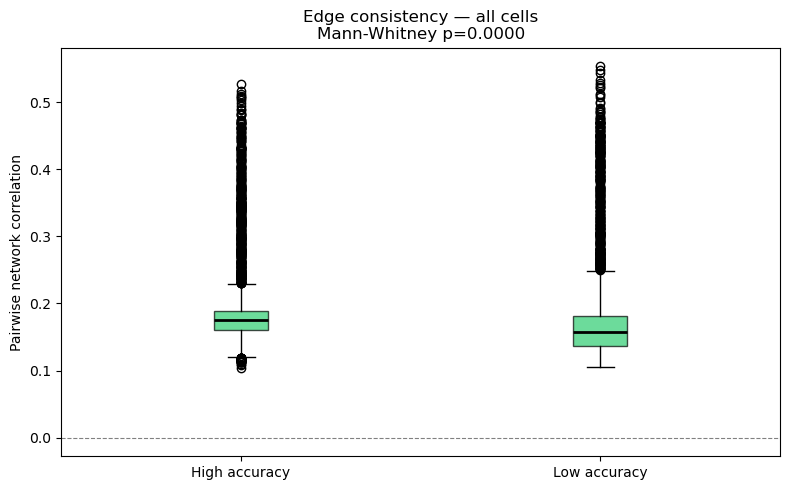

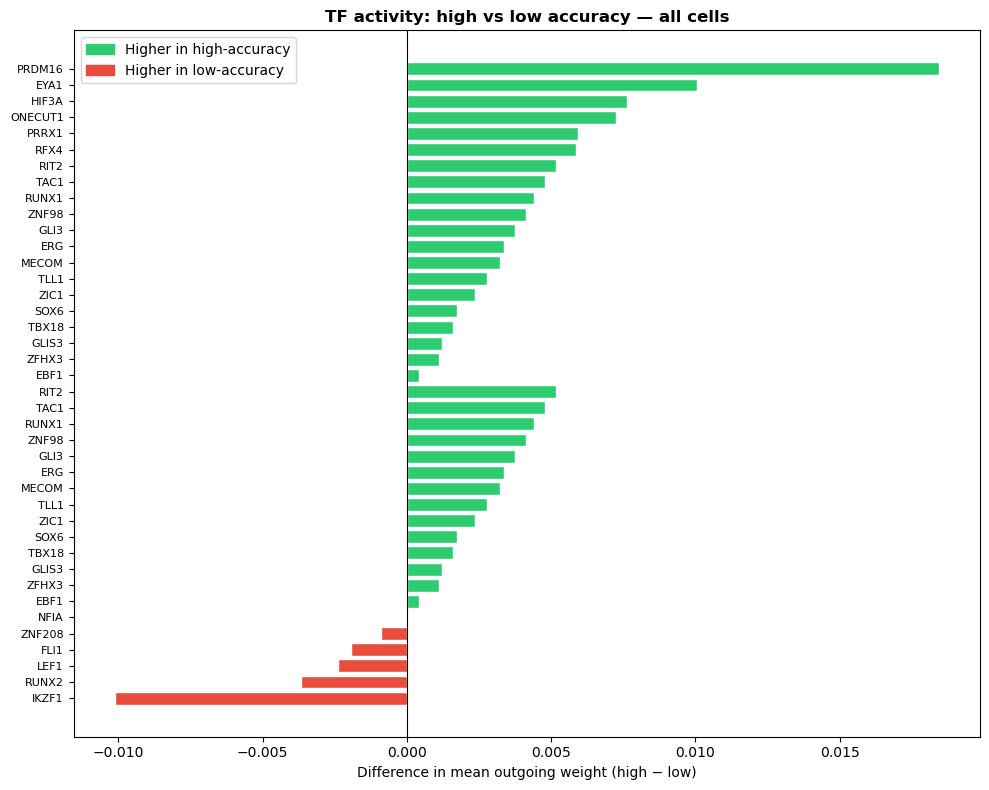

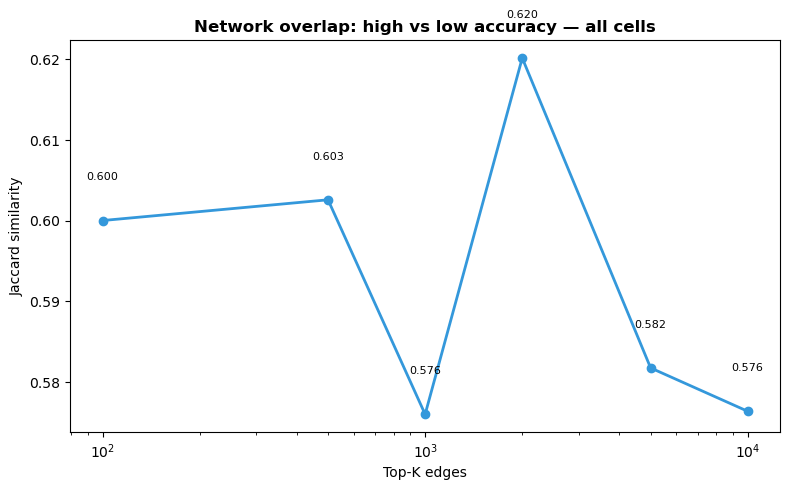

In [20]:
high_networks = networks[high_idx]
low_networks  = networks[low_idx]

high_mean_net = high_networks.mean(axis=0)
low_mean_net  = low_networks.mean(axis=0)

high_corrs = pairwise_correlations(high_networks)
low_corrs  = pairwise_correlations(low_networks)

stat, pval = mannwhitneyu(high_corrs, low_corrs, alternative="greater")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([high_corrs, low_corrs],
           labels=["High accuracy", "Low accuracy"],
           patch_artist=True,
           boxprops=dict(facecolor="#2ecc71", alpha=0.7),
           medianprops=dict(color="black", linewidth=2))
ax.set_ylabel("Pairwise network correlation")
ax.set_title(f"Edge consistency — all cells\nMann-Whitney p={pval:.4f}")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("optA_edge_consistency.png", dpi=150)
plt.show()

tf_activity = []
for tf in tf_genes:
    if tf not in gene_to_idx:
        continue
    idx = gene_to_idx[tf]
    high_out = high_mean_net[:, idx].sum()
    low_out  = low_mean_net[:, idx].sum()
    tf_activity.append({
        "TF":            tf,
        "high_activity": high_out,
        "low_activity":  low_out,
        "diff":          high_out - low_out,
    })

tf_df = pd.DataFrame(tf_activity).sort_values("diff", ascending=False)
top_tf   = tf_df.head(20)
bot_tf   = tf_df.tail(20)
plot_tf  = pd.concat([top_tf, bot_tf])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in plot_tf["diff"]]
ax.barh(range(len(plot_tf)), plot_tf["diff"].values, color=colors, edgecolor="white")
ax.set_yticks(range(len(plot_tf)))
ax.set_yticklabels(plot_tf["TF"].values, fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Difference in mean outgoing weight (high − low)")
ax.set_title("TF activity: high vs low accuracy — all cells", fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2ecc71", label="Higher in high-accuracy"),
    Patch(color="#e74c3c", label="Higher in low-accuracy"),
])
plt.tight_layout()
plt.savefig("optA_tf_activity.png", dpi=150)
plt.show()

top_ks   = [100, 500, 1000, 2000, 5000, 10000]
jaccards = [jaccard(binarise(high_mean_net, top_k=k),
                    binarise(low_mean_net,  top_k=k)) for k in top_ks]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(top_ks, jaccards, marker="o", color="#3498db", linewidth=2)
ax.set_xlabel("Top-K edges")
ax.set_ylabel("Jaccard similarity")
ax.set_title("Network overlap: high vs low accuracy — all cells", fontweight="bold")
ax.set_xscale("log")
for k, j in zip(top_ks, jaccards):
    ax.text(k, j + 0.005, f"{j:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("optA_jaccard.png", dpi=150)
plt.show()


Cell type: Endothelial
  High accuracy cells: 6, mean R$^2$=-0.0128
  Low accuracy cells : 11, mean R$^2$=-0.1066


C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\726584343.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([ct_high_corrs, ct_low_corrs],


Non-zero edges — high: 49215, low: 50946, cap: 49215


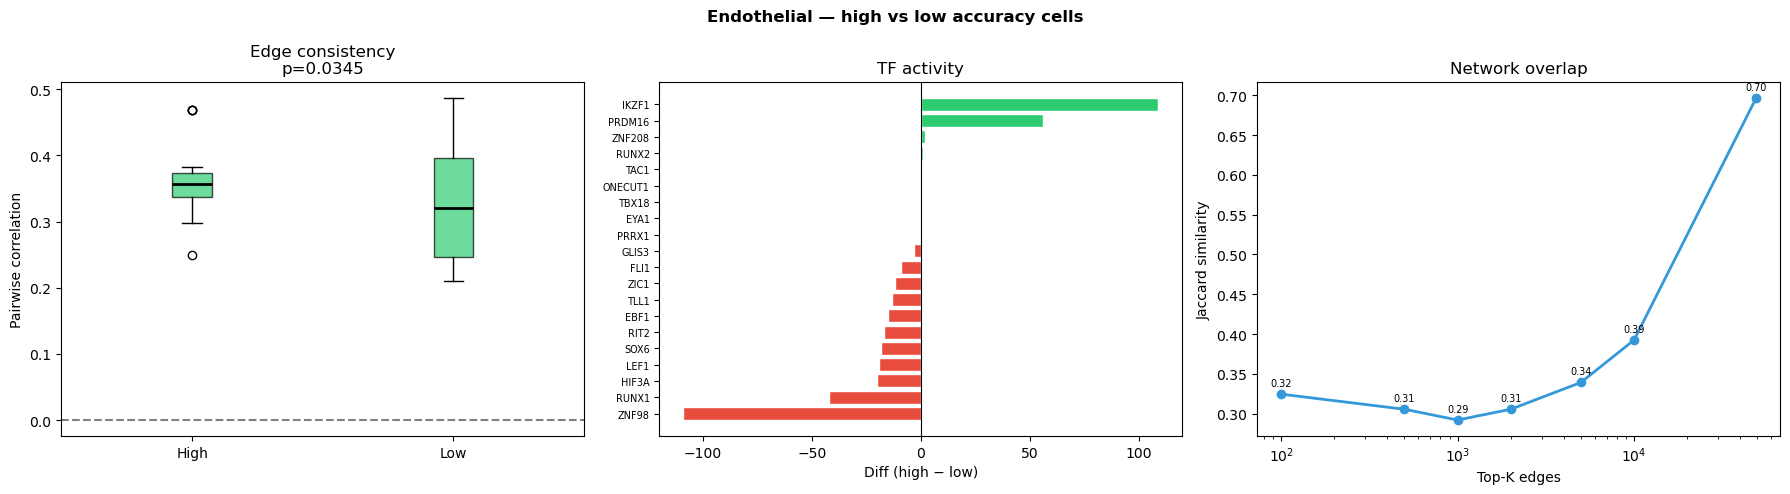


Cell type: L5 IT
  High accuracy cells: 6, mean R$^2$=-0.0102
  Low accuracy cells : 10, mean R$^2$=-0.1017


C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\726584343.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([ct_high_corrs, ct_low_corrs],


Non-zero edges — high: 111587, low: 108221, cap: 108221


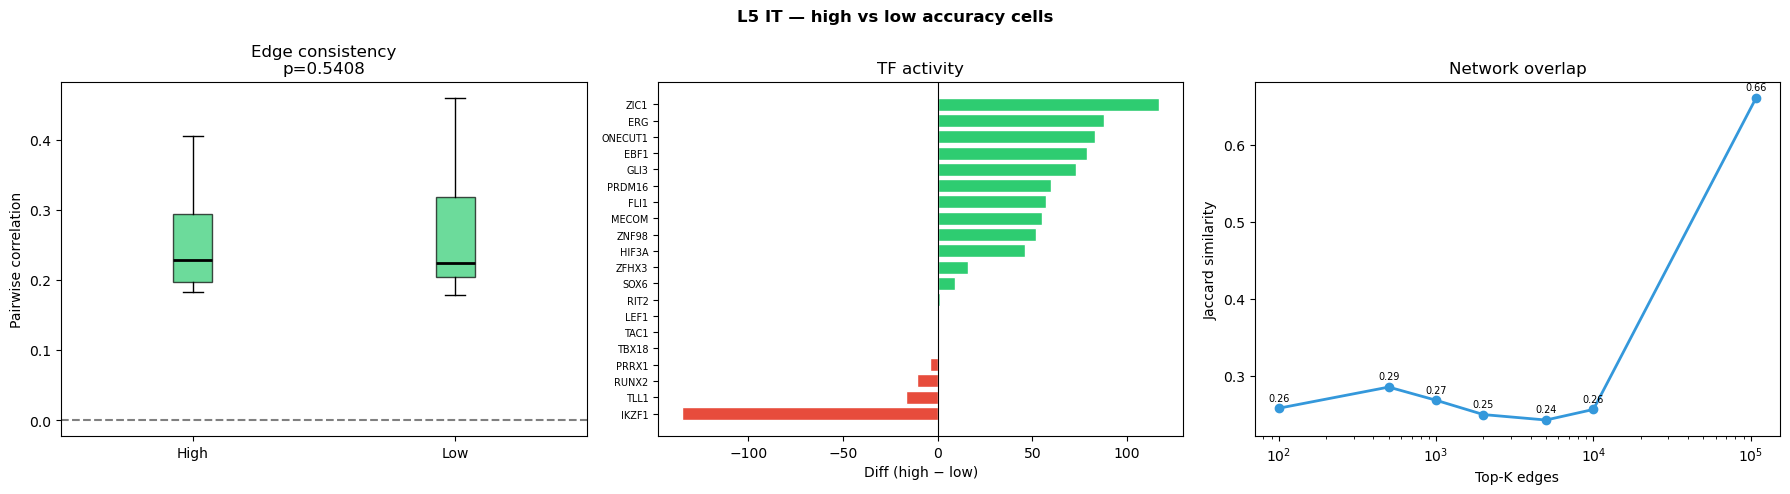


Cell type: Sst
  High accuracy cells: 6, mean R$^2$=0.0003
  Low accuracy cells : 7, mean R$^2$=-0.1037
Non-zero edges — high: 82843, low: 67124, cap: 67124


C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\726584343.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([ct_high_corrs, ct_low_corrs],


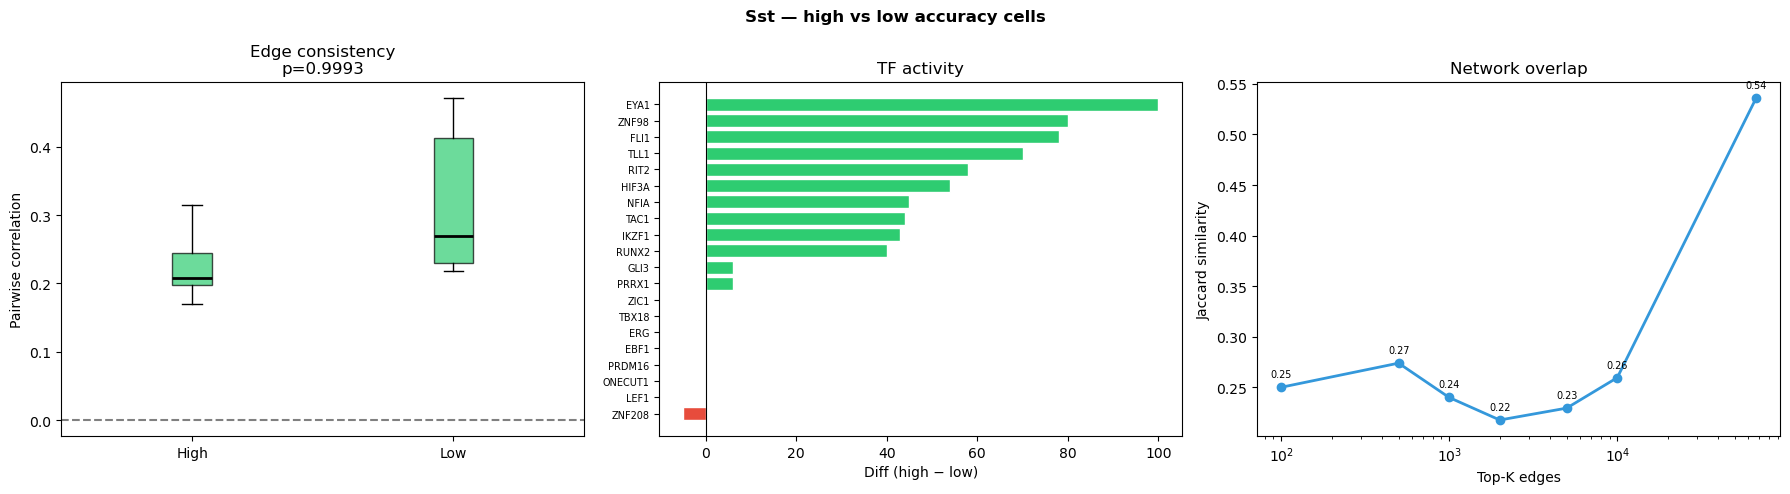

In [21]:
MATCHED_TYPES = ["Endothelial", "L5 IT", "Sst"]

for ct in MATCHED_TYPES:
    print(f"\n{'='*50}")
    print(f"Cell type: {ct}")

    ct_mask     = cell_type == ct
    ct_high_idx = np.where(ct_mask & high_mask)[0]
    ct_low_idx  = np.where(ct_mask & low_mask)[0]

    print(f"  High accuracy cells: {len(ct_high_idx)}, "
          f"mean R$^2$={cell_r2.iloc[ct_high_idx].mean():.4f}")
    print(f"  Low accuracy cells : {len(ct_low_idx)}, "
          f"mean R$^2$={cell_r2.iloc[ct_low_idx].mean():.4f}")

    ct_high_nets = networks[ct_high_idx]
    ct_low_nets  = networks[ct_low_idx]

    ct_high_mean = ct_high_nets.mean(axis=0)
    ct_low_mean  = ct_low_nets.mean(axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{ct} — high vs low accuracy cells", fontweight="bold")

    if len(ct_high_idx) > 1 and len(ct_low_idx) > 1:
        ct_high_corrs = pairwise_correlations(ct_high_nets)
        ct_low_corrs  = pairwise_correlations(ct_low_nets)
        stat, pval = mannwhitneyu(ct_high_corrs, ct_low_corrs, alternative="greater")

        axes[0].boxplot([ct_high_corrs, ct_low_corrs],
                        labels=["High", "Low"],
                        patch_artist=True,
                        boxprops=dict(facecolor="#2ecc71", alpha=0.7),
                        medianprops=dict(color="black", linewidth=2))
        axes[0].set_ylabel("Pairwise correlation")
        axes[0].set_title(f"Edge consistency\np={pval:.4f}")
        axes[0].axhline(0, color="grey", linestyle="--")
    else:
        axes[0].text(0.5, 0.5, "Not enough cells\nfor pairwise comparison",
                     ha="center", va="center", transform=axes[0].transAxes)
        axes[0].set_title("Edge consistency")

    ct_tf = []
    for tf in tf_genes:
        if tf not in gene_to_idx:
            continue
        i = gene_to_idx[tf]
        ct_tf.append({
            "TF":   tf,
            "diff": (ct_high_mean[:, i] > 0).sum() - (ct_low_mean[:, i] > 0).sum(),

        })

    ct_tf_df  = pd.DataFrame(ct_tf).sort_values("diff", ascending=False)
    plot_ct   = pd.concat([ct_tf_df.head(10), ct_tf_df.tail(10)])
    colors_ct = ["#2ecc71" if d > 0 else "#e74c3c" for d in plot_ct["diff"]]

    axes[1].barh(range(len(plot_ct)), plot_ct["diff"].values,
                 color=colors_ct, edgecolor="white")
    axes[1].set_yticks(range(len(plot_ct)))
    axes[1].set_yticklabels(plot_ct["TF"].values, fontsize=7)
    axes[1].invert_yaxis()
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].set_xlabel("Diff (high − low)")
    axes[1].set_title("TF activity")

    high_nonzero = (ct_high_mean > 0).sum()
    low_nonzero  = (ct_low_mean > 0).sum()
    max_k = min(high_nonzero, low_nonzero)
    print(f"Non-zero edges — high: {high_nonzero}, low: {low_nonzero}, cap: {max_k}")

    top_ks   = [k for k in [100, 500, 1000, 2000, 5000, 10000] if k <= max_k]
    top_ks.append(max_k)
    top_ks   = sorted(set(top_ks))

    jaccards = [jaccard(binarise(ct_high_mean, top_k=k),
                        binarise(ct_low_mean,  top_k=k)) for k in top_ks]

    axes[2].plot(top_ks, jaccards, marker="o", color="#3498db", linewidth=2)
    axes[2].set_xscale("log")
    axes[2].set_xlabel("Top-K edges")
    axes[2].set_ylabel("Jaccard similarity")
    axes[2].set_title("Network overlap")
    for k, j in zip(top_ks, jaccards):
        axes[2].text(k, j + 0.01, f"{j:.2f}", ha="center", fontsize=7)

    plt.tight_layout()
    plt.savefig(f"optB_{ct.replace('/', '_')}_comparison.png", dpi=150)
    plt.show()


Cell type: Endothelial
  High accuracy cells: 6, mean R$^2$=-0.0128
  Low accuracy cells : 11, mean R$^2$=-0.1066
Non-zero edges (>0.0001) — high: 29163, low: 28779, cap: 28779


C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\2704081893.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([ct_high_corrs, ct_low_corrs],


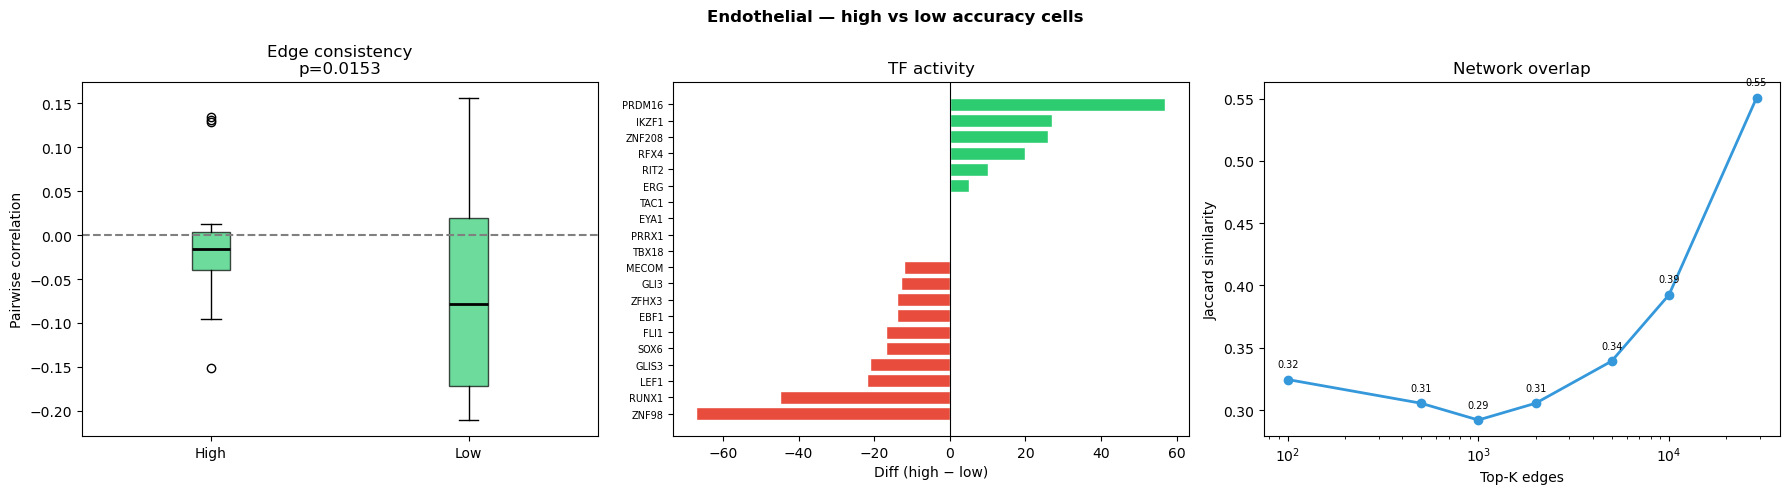


Cell type: L5 IT
  High accuracy cells: 6, mean R$^2$=-0.0102
  Low accuracy cells : 10, mean R$^2$=-0.1017


C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\2704081893.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([ct_high_corrs, ct_low_corrs],


Non-zero edges (>0.0001) — high: 57075, low: 49807, cap: 49807


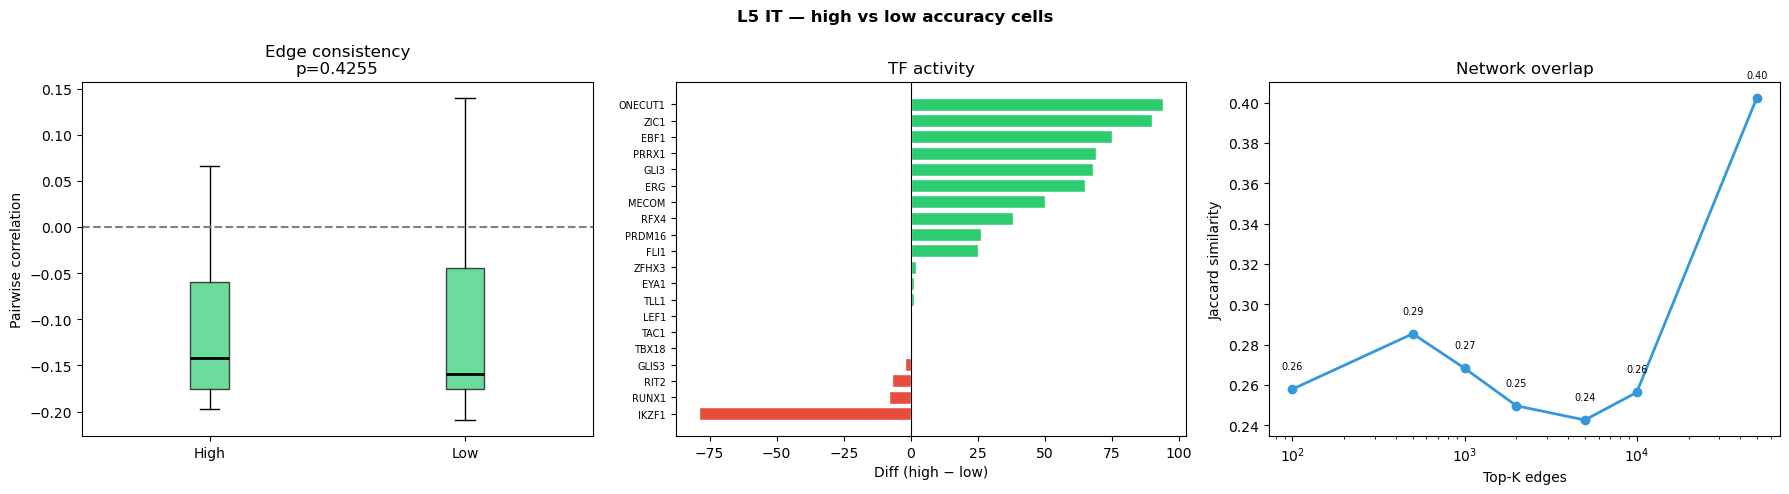


Cell type: Sst
  High accuracy cells: 6, mean R$^2$=0.0003
  Low accuracy cells : 7, mean R$^2$=-0.1037
Non-zero edges (>0.0001) — high: 47166, low: 38236, cap: 38236


C:\Users\Edi\AppData\Local\Temp\ipykernel_36532\2704081893.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([ct_high_corrs, ct_low_corrs],


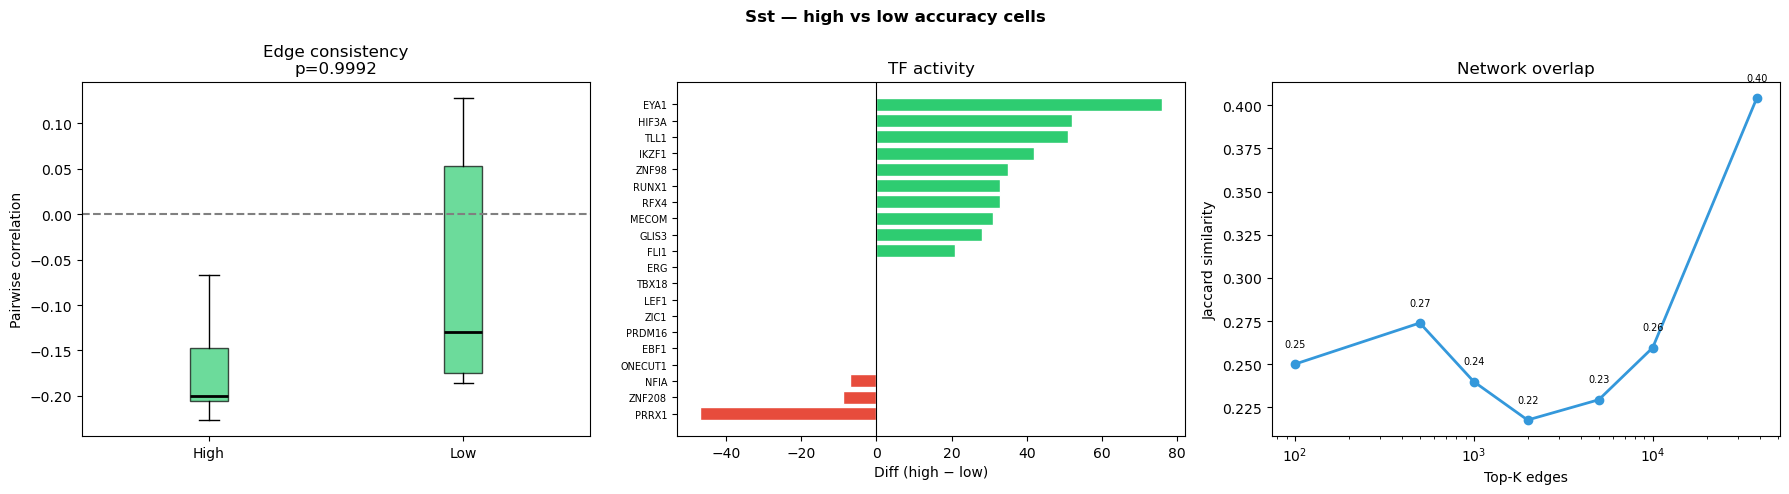

In [22]:
MATCHED_TYPES = ["Endothelial", "L5 IT", "Sst"]
WEIGHT_THRESHOLD = 0.0001

def pairwise_correlations(nets, threshold=0.0):
    n = len(nets)
    corrs = []
    for i in range(n):
        for j in range(i+1, n):
            mask = (nets[i] > threshold) | (nets[j] > threshold)
            if mask.sum() == 0:
                continue
            c = np.corrcoef(nets[i][mask], nets[j][mask])[0, 1]
            corrs.append(c)
    return np.array(corrs)

for ct in MATCHED_TYPES:
    print(f"\n{'='*50}")
    print(f"Cell type: {ct}")

    ct_mask     = cell_type == ct
    ct_high_idx = np.where(ct_mask & high_mask)[0]
    ct_low_idx  = np.where(ct_mask & low_mask)[0]

    print(f"  High accuracy cells: {len(ct_high_idx)}, "
          f"mean R$^2$={cell_r2.iloc[ct_high_idx].mean():.4f}")
    print(f"  Low accuracy cells : {len(ct_low_idx)}, "
          f"mean R$^2$={cell_r2.iloc[ct_low_idx].mean():.4f}")

    ct_high_nets = networks[ct_high_idx]
    ct_low_nets  = networks[ct_low_idx]

    ct_high_mean = ct_high_nets.mean(axis=0)
    ct_low_mean  = ct_low_nets.mean(axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{ct} — high vs low accuracy cells", fontweight="bold")

    if len(ct_high_idx) > 1 and len(ct_low_idx) > 1:
        ct_high_corrs = pairwise_correlations(ct_high_nets, threshold=WEIGHT_THRESHOLD)
        ct_low_corrs  = pairwise_correlations(ct_low_nets,  threshold=WEIGHT_THRESHOLD)
        stat, pval = mannwhitneyu(ct_high_corrs, ct_low_corrs, alternative="greater")

        axes[0].boxplot([ct_high_corrs, ct_low_corrs],
                        labels=["High", "Low"],
                        patch_artist=True,
                        boxprops=dict(facecolor="#2ecc71", alpha=0.7),
                        medianprops=dict(color="black", linewidth=2))
        axes[0].set_ylabel("Pairwise correlation")
        axes[0].set_title(f"Edge consistency\np={pval:.4f}")
        axes[0].axhline(0, color="grey", linestyle="--")
    else:
        axes[0].text(0.5, 0.5, "Not enough cells\nfor pairwise comparison",
                     ha="center", va="center", transform=axes[0].transAxes)
        axes[0].set_title("Edge consistency")

    ct_tf = []
    for tf in tf_genes:
        if tf not in gene_to_idx:
            continue
        i = gene_to_idx[tf]
        ct_tf.append({
            "TF":   tf,
            "diff": (ct_high_mean[:, i] > WEIGHT_THRESHOLD).sum() - (ct_low_mean[:, i] > WEIGHT_THRESHOLD).sum(),

        })

    ct_tf_df  = pd.DataFrame(ct_tf).sort_values("diff", ascending=False)
    plot_ct   = pd.concat([ct_tf_df.head(10), ct_tf_df.tail(10)])
    colors_ct = ["#2ecc71" if d > 0 else "#e74c3c" for d in plot_ct["diff"]]

    axes[1].barh(range(len(plot_ct)), plot_ct["diff"].values,
                 color=colors_ct, edgecolor="white")
    axes[1].set_yticks(range(len(plot_ct)))
    axes[1].set_yticklabels(plot_ct["TF"].values, fontsize=7)
    axes[1].invert_yaxis()
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].set_xlabel("Diff (high − low)")
    axes[1].set_title("TF activity")


    high_nonzero = (ct_high_mean > WEIGHT_THRESHOLD).sum()
    low_nonzero  = (ct_low_mean  > WEIGHT_THRESHOLD).sum()
    max_k        = min(high_nonzero, low_nonzero)
    print(f"Non-zero edges (>{WEIGHT_THRESHOLD}) — high: {high_nonzero}, low: {low_nonzero}, cap: {max_k}")

    top_ks   = [k for k in [100, 500, 1000, 2000, 5000, 10000] if k <= max_k]
    top_ks.append(max_k)
    top_ks   = sorted(set(top_ks))

    jaccards = [jaccard(binarise(ct_high_mean, top_k=k),
                        binarise(ct_low_mean,  top_k=k)) for k in top_ks]

    axes[2].plot(top_ks, jaccards, marker="o", color="#3498db", linewidth=2)
    axes[2].set_xscale("log")
    axes[2].set_xlabel("Top-K edges")
    axes[2].set_ylabel("Jaccard similarity")
    axes[2].set_title("Network overlap")
    for k, j in zip(top_ks, jaccards):
        axes[2].text(k, j + 0.01, f"{j:.2f}", ha="center", fontsize=7)

    plt.tight_layout()
    plt.savefig(f"optB_{ct.replace('/', '_')}_comparison.png", dpi=150)
    plt.show()

In [23]:
genes = rna.var_names.tolist()

X = rna.X.toarray() if sp.issparse(rna.X) else rna.X
expr_df = pd.DataFrame(
    X.T,
    index   = rna.var_names,
    columns = rna.obs_names,
)

In [24]:

mean_network = networks.mean(axis=0)

In [25]:
import networkx as nx
from scipy import stats

TOP_K = 500

all_in_degree    = np.zeros((len(networks), len(genes)))
all_out_degree   = np.zeros((len(networks), len(genes)))
all_betweenness  = np.zeros((len(networks), len(genes)))
all_pagerank     = np.zeros((len(networks), len(genes)))

gene_to_pos = {g: i for i, g in enumerate(genes)}

for cell_idx in range(len(networks)):
    net = networks[cell_idx]
    flat = net.flatten()
    threshold = np.sort(flat)[-TOP_K]

    G = nx.DiGraph()
    rows, cols = np.where(net >= threshold)
    for r, c in zip(rows, cols):
        if r != c:
            G.add_edge(genes[c], genes[r], weight=net[r, c])

    in_deg  = dict(G.in_degree())
    out_deg = dict(G.out_degree())
    betw    = nx.betweenness_centrality(G, weight="weight")
    pr      = nx.pagerank(G, weight="weight") if G.number_of_edges() > 0 else {}

    for gene in G.nodes():
        pos = gene_to_pos[gene]
        all_in_degree[cell_idx, pos]   = in_deg.get(gene, 0)
        all_out_degree[cell_idx, pos]  = out_deg.get(gene, 0)
        all_betweenness[cell_idx, pos] = betw.get(gene, 0)
        all_pagerank[cell_idx, pos]    = pr.get(gene, 0)

in_degree   = dict(zip(genes, all_in_degree.mean(axis=0)))
out_degree  = dict(zip(genes, all_out_degree.mean(axis=0)))
betweenness = dict(zip(genes, all_betweenness.mean(axis=0)))
pagerank    = dict(zip(genes, all_pagerank.mean(axis=0)))

In [26]:
print("In-degree stats:", pd.Series(in_degree).describe())
print("Out-degree stats:", pd.Series(out_degree).describe())
print("Betweenness stats:", pd.Series(betweenness).describe())
print("Pagerank stats:", pd.Series(pagerank).describe())

print(f"\nGenes with non-zero in-degree: {(np.array(list(in_degree.values())) > 0).sum()} / 500")
print(f"Genes with non-zero out-degree: {(np.array(list(out_degree.values())) > 0).sum()} / 500")

In-degree stats: count    500.000000
mean       1.005855
std        4.425721
min        0.000000
25%        0.070000
50%        0.170833
75%        0.727500
max       87.872500
dtype: float64
Out-degree stats: count    500.000000
mean       1.005855
std        0.478008
min        0.000000
25%        0.767917
50%        1.021250
75%        1.267083
max        4.455833
dtype: float64
Betweenness stats: count    500.000000
mean       0.000303
std        0.001202
min        0.000000
25%        0.000024
50%        0.000060
75%        0.000209
max        0.022104
dtype: float64
Pagerank stats: count    500.000000
mean       0.002000
std        0.006732
min        0.000000
25%        0.000697
50%        0.001164
75%        0.001871
max        0.142032
dtype: float64

Genes with non-zero in-degree: 498 / 500
Genes with non-zero out-degree: 498 / 500


In [27]:
centrality_df = pd.DataFrame({
    "gene":        genes,
    "in_degree":   [in_degree.get(g, 0) for g in genes],
    "out_degree":  [out_degree.get(g, 0) for g in genes],
    "betweenness": [betweenness.get(g, 0) for g in genes],
    "pagerank":    [pagerank.get(g, 0) for g in genes],
    "gene_r2":     gene_r2.values,
})

for col in ["in_degree", "out_degree", "betweenness", "pagerank"]:
    r, p = stats.spearmanr(centrality_df["gene_r2"], centrality_df[col], nan_policy="omit")
    print(f"Gene R$^2$ vs {col}: r={r:.4f}, p={p:.2e}")

Gene R$^2$ vs in_degree: r=0.4122, p=7.50e-22
Gene R$^2$ vs out_degree: r=0.0321, p=4.75e-01
Gene R$^2$ vs betweenness: r=0.2867, p=7.04e-11
Gene R$^2$ vs pagerank: r=0.4091, p=1.62e-21


In [28]:
print(centrality_df[["gene_r2", "in_degree", "out_degree", "betweenness", "pagerank"]].isna().sum())

gene_r2        2
in_degree      0
out_degree     0
betweenness    0
pagerank       0
dtype: int64


In [29]:
centrality_df[["gene_r2", "in_degree"]].info()
print(centrality_df["gene_r2"].nunique())
print(centrality_df["gene_r2"].std())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   gene_r2    498 non-null    float64
 1   in_degree  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB
498
0.02872547540416156


In [30]:
labels = pd.read_csv(f"{BASE}_gene_labels.csv")
gene_type_map = dict(zip(labels["gene"], labels["type"]))

centrality_df["type"] = centrality_df["gene"].map(gene_type_map)

tf_r2     = centrality_df[centrality_df["type"] == "TF"]["gene_r2"]
target_r2 = centrality_df[centrality_df["type"] == "target"]["gene_r2"]

stat, p = stats.mannwhitneyu(tf_r2, target_r2, alternative="two-sided")
print(f"TF vs target R$^2$: TF mean={tf_r2.mean():.4f}, Target mean={target_r2.mean():.4f}, p={p:.4f}")

TF vs target R$^2$: TF mean=-0.0546, Target mean=-0.0721, p=nan


In [31]:
labels["n_peaks"] = labels["associated_peaks"].apply(
    lambda x: 0 if pd.isna(x) else len(str(x).split(","))
)
labels["n_tfs"] = labels["associated_TFs"].apply(
    lambda x: 0 if pd.isna(x) else len(str(x).split(","))
)

merged = centrality_df.merge(labels[["gene", "n_peaks", "n_tfs"]], on="gene")

for col in ["n_peaks", "n_tfs"]:
    r, p = stats.spearmanr(merged["gene_r2"], merged[col], nan_policy="omit")
    print(f"Gene R$^2$ vs {col}: r={r:.4f}, p={p:.2e}")

Gene R$^2$ vs n_peaks: r=0.2199, p=7.17e-07
Gene R$^2$ vs n_tfs: r=0.2225, p=5.28e-07


In [32]:
mean_outgoing = mean_network.mean(axis=0)
mean_incoming = mean_network.mean(axis=1)

centrality_df["mean_outgoing_weight"] = mean_outgoing
centrality_df["mean_incoming_weight"] = mean_incoming

for col in ["mean_outgoing_weight", "mean_incoming_weight"]:
    r, p = stats.spearmanr(centrality_df["gene_r2"], centrality_df[col], nan_policy="omit")
    print(f"Gene R$^2$ vs {col}: r={r:.4f}, p={p:.2e}")

Gene R$^2$ vs mean_outgoing_weight: r=0.5201, p=7.38e-36
Gene R$^2$ vs mean_incoming_weight: r=0.4415, p=3.56e-25


In [33]:
G_undirected = G.to_undirected()
communities = nx.community.louvain_communities(G_undirected, weight="weight", seed=42)

gene_to_community = {}
for comm_idx, comm in enumerate(communities):
    for gene in comm:
        gene_to_community[gene] = comm_idx

centrality_df["community"] = centrality_df["gene"].map(gene_to_community)
community_sizes = centrality_df["community"].value_counts()
centrality_df["community_size"] = centrality_df["community"].map(community_sizes)

r, p = stats.spearmanr(centrality_df["gene_r2"], centrality_df["community_size"])
print(f"Gene R$^2$ vs community size: r={r:.4f}, p={p:.2e}")

Gene R$^2$ vs community size: r=nan, p=nan


In [34]:
gene_mean_expr = expr_df.mean(axis=1).values
gene_var_expr  = expr_df.var(axis=1).values

merged["mean_outgoing_weight"] = mean_outgoing
merged["mean_incoming_weight"] = mean_incoming
merged["mean_expr_gene"] = gene_mean_expr

r1, p1 = stats.spearmanr(gene_r2.values, gene_mean_expr, nan_policy="omit")
r2, p2 = stats.spearmanr(gene_r2.values, gene_var_expr, nan_policy="omit")
print(f"Gene R$^2$ vs mean expression: r={r1:.4f}, p={p1:.2e}")
print(f"Gene R$^2$ vs expression variance: r={r2:.4f}, p={p2:.2e}")

Gene R$^2$ vs mean expression: r=0.6733, p=4.91e-67
Gene R$^2$ vs expression variance: r=0.5919, p=2.13e-48


In [35]:
print((merged["gene"].values == expr_df.index.values).all())

True


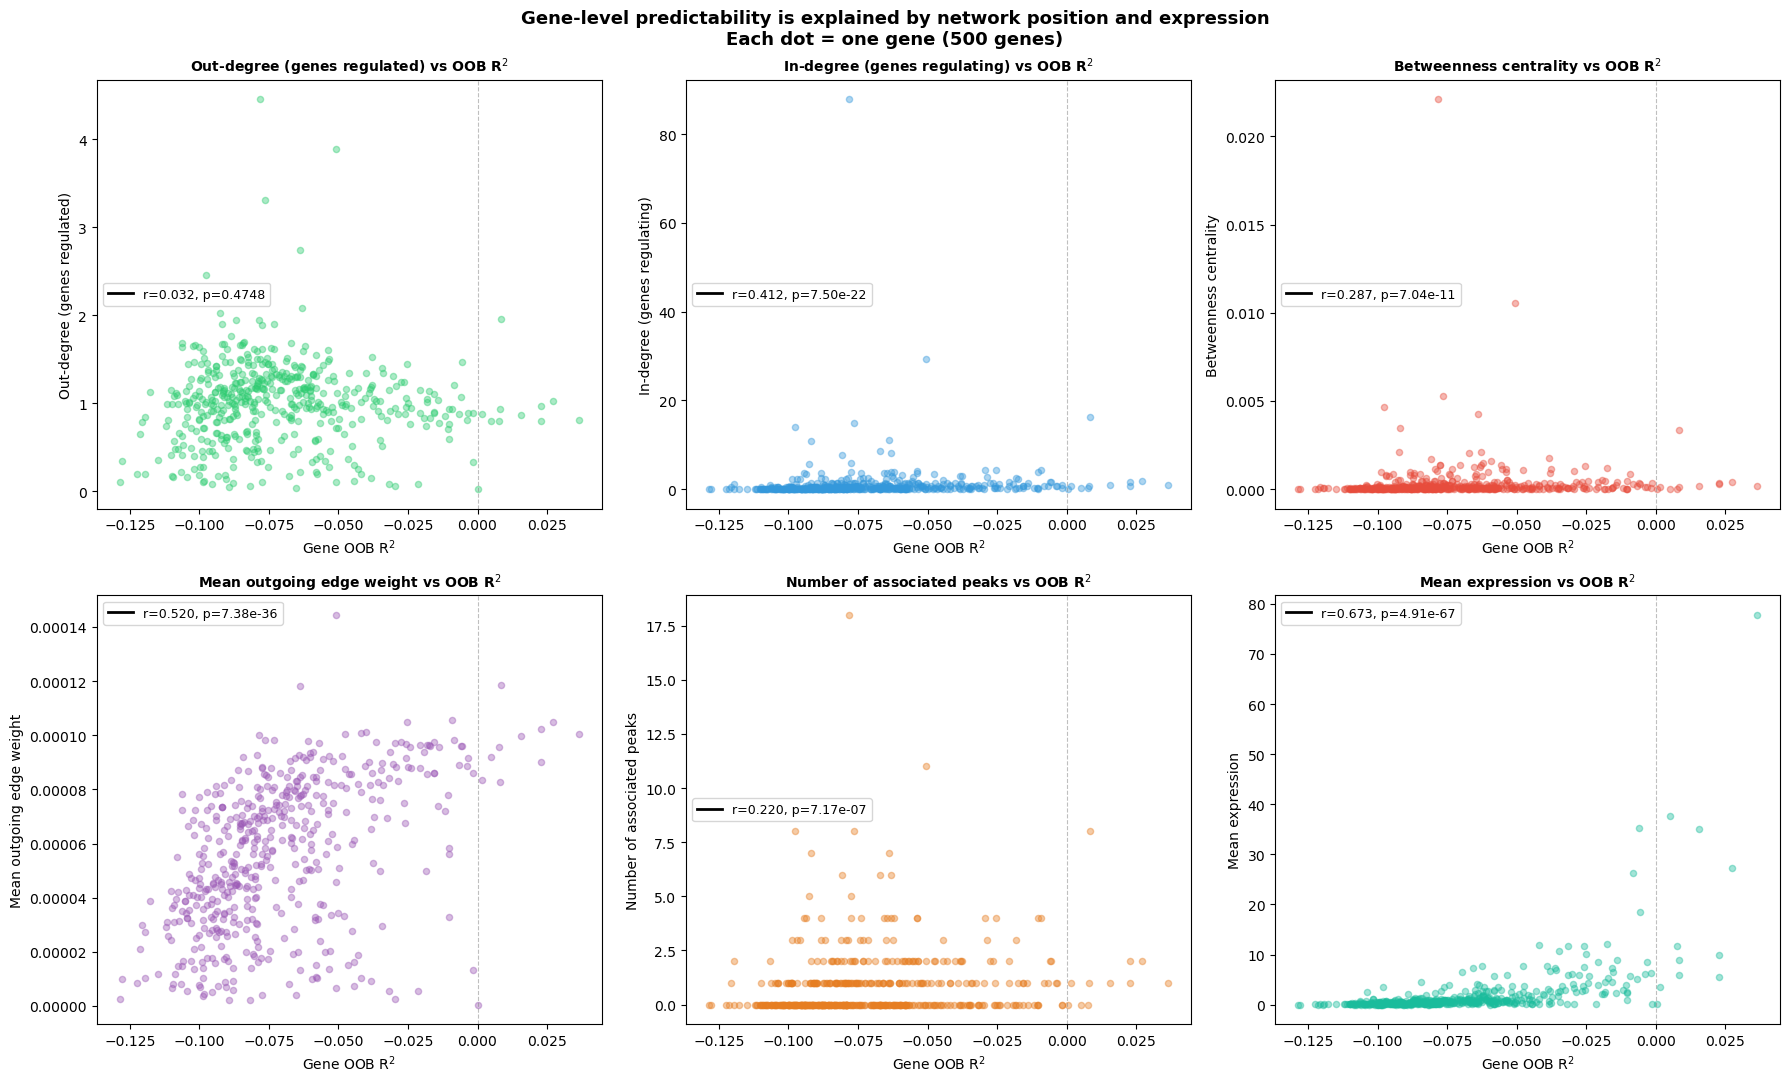

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

plot_specs = [
    ("out_degree",            "Out-degree (genes regulated)",  "#2ecc71"),
    ("in_degree",              "In-degree (genes regulating)",  "#3498db"),
    ("betweenness",            "Betweenness centrality",        "#e74c3c"),
    ("mean_outgoing_weight",   "Mean outgoing edge weight",     "#9b59b6"),
    ("n_peaks",                "Number of associated peaks",    "#e67e22"),
    ("mean_expr_gene",         "Mean expression",               "#1abc9c"),
]

for ax, (col, label, color) in zip(axes.flat, plot_specs):
    r, p = stats.spearmanr(merged["gene_r2"], merged[col], nan_policy="omit")
    p_str = f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

    ax.scatter(merged["gene_r2"], merged[col], alpha=0.4, s=20, color=color)

    slope, intercept, _, _, _ = stats.linregress(merged["gene_r2"], merged[col])
    x = np.linspace(merged["gene_r2"].min(), merged["gene_r2"].max(), 100)
    ax.plot(x, slope*x + intercept, color="black", linewidth=2,
            label=f"r={r:.3f}, p={p_str}")

    ax.set_xlabel("Gene OOB R$^2$", fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f"{label} vs OOB R$^2$", fontweight="bold", fontsize=10)
    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=9)

fig.suptitle(
    "Gene-level predictability is explained by network position and expression\n"
    "Each dot = one gene (500 genes)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("gene_r2_network_position.png", dpi=150, bbox_inches="tight")
plt.show()